# Assignment 1: BigMart Predictive Sales Analytics

---

### 1. Executive Summary & Business Objective
**BigMart** operates a highly diverse, multi-format retail network spanning several metropolitan and tier-structured cities. Sustaining profitability and optimizing inventory turnover depends heavily on understanding the underlying drivers of product demand. 

The primary objective of this initiative is to construct a robust, statistically sound **Linear Regression** model to predict individual product yields (`Item_Outlet_Sales`). By leveraging historical item attributes and store-specific operational characteristics, this predictive framework aims to:
* **Optimize Inventory Placement:** Ensure high-demand stock is correctly allocated to high-performing outlets.
* **Mitigate Stockouts and Shrinkage:** Minimize revenue leakage caused by supply chain bottlenecks or over-stocking.
* **Drive Strategic Decision-Making:** Uncover critical, non-causal associations between retail properties (e.g., store size, visibility) and gross sales.

### 2. Technical Implementation Strategy
To ensure reproducible, production-grade machine learning code, this workflow bypasses ad-hoc data manipulations in favor of an automated **Scikit-Learn Preprocessing Pipeline**. The technical implementation enforces standard data science guardrails:
* **Robust Imputation & Scaling:** Missing data is programmatically resolved using median/most-frequent strategies, and numerical distributions are scaled to prevent magnitude bias.
* **Strict Leakage Prevention:** Data preprocessing transforms are fit exclusively on the training subset and applied downstream to validation and unseen test pools.
* **Rigorous Assumption Diagnostics:** Beyond standard aggregate metrics (R², RMSE), the model's structural validity is vetted via comprehensive residual plot analysis.

---

### 3. Structured Project Execution Framework
This notebook details an end-to-end machine learning lifecycle, strictly segmented into **16 Operational Tasks**:

* **Phase I: Data Acquisition & Structural Auditing**
  1. **Load Dataset**: Ingest train/test data arrays and conduct an initial structural inspection of the top 10 records.
  2. **Dataset Structure**: Profile the dimensional scope (row/column counts) and map primitive data types.
  3. **Missing Value Audit**: Enumerate missing data densities and isolate systemic `Item_Visibility` zero-value anomalies.

* **Phase II: Clean Room Operations & Exploratory Data Analysis (EDA)**
  4. **Data Cleaning**: Standardize disparate categorical strings, convert structural zeros to missing values, and engineer domain-specific features.
  5. **Variable Classification**: Isolate the target array (y) and logically partition predictors (X) into numeric and categorical vectors.
  6. **Numerical EDA**: Statistically evaluate feature distributions, central tendencies, and directional skewness.
  7. **Target Relationships**: Evaluate the bivariate behavior of product and outlet dimensions against `Item_Outlet_Sales`.
  8. **Correlation Analysis**: Map linear dependencies between numerical features using an annotated covariance/correlation heatmap.

* **Phase III: Pipeline Engineering & Model Training**
  9. **Pipeline Preprocessing**: Architect an automated `ColumnTransformer` integrating `SimpleImputer`, `StandardScaler`, and out-of-sample resilient `OneHotEncoder(handle_unknown="ignore")`.
  10. **Train-Test Split**: Implement a rigorous 80/20 partition on labeled historical data to build distinct training and validation sets.
  11. **Feature/Target Definition**: Formally declare independent feature spaces (X) and the dependent target vector (y).
  12. **Model Training**: Fit a generalized `LinearRegression` model through the encapsulated preprocessing pipeline exclusively on training data.

* **Phase IV: Validation, Diagnostics & Inference**
  13. **Sales Prediction**: Generate validation predictions for immediate evaluation, followed by full-sample model retraining to output finalized predictions for `test.csv`.
  14. **Model Evaluation & Residuals**: Quantify error bounds (R², MAE, MSE, RMSE) and rigorously test linear regression assumptions via residual distribution analysis.
  15. **Coefficient Interpretation**: Extract and decode the model's weights mathematically, strictly avoiding causal claims or misleading "feature importance" naming conventions.
  16. **Key Insights & Business Summary**: Synthesize empirical findings into actionable, numbers-driven corporate strategies for BigMart leadership.


## 1. Import Libraries and Configuration

In [35]:
# 1. Import required libraries and configure environment
import warnings
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# To ignore non-critical warnings
warnings.filterwarnings("ignore")

# Configure visualization style
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["font.size"] = 10
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11

# Data Sources
RANDOM_STATE = 42
TRAIN_URL = "https://raw.githubusercontent.com/ammishra08/Machine-Learning/refs/heads/master/Datasets/bigmart_train.csv"
TEST_URL = "https://raw.githubusercontent.com/ammishra08/Machine-Learning/refs/heads/master/Datasets/bigmart_test.csv"
TARGET = "Item_Outlet_Sales"
DATASET_BASE_YEAR = 2013

print("Libraries successfully imported and configuration initialized.")

Libraries successfully imported and configuration initialized.


## Task 1: Load Dataset and Display First 10 Records

Load the labeled training dataset and test dataset from the assignment URLs, then display the first 10 records of the training set.

In [36]:
# Task 1: Load datasets and display the first 10 records
train_df = pd.read_csv(TRAIN_URL)
test_df = pd.read_csv(TEST_URL)

print(f"Training dataset shape: {train_df.shape[0]:,} rows, {train_df.shape[1]} columns")
print(f"Test dataset shape:     {test_df.shape[0]:,} rows, {test_df.shape[1]} columns")

print("\nFirst 10 records of BigMart Training Dataset:")
display(train_df.head(10))

Training dataset shape: 8,523 rows, 12 columns
Test dataset shape:     5,681 rows, 11 columns

First 10 records of BigMart Training Dataset:


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
5,FDP36,10.395,Regular,0.000000,Baking Goods,51.4008,OUT018,2009,Medium,Tier 3,Supermarket Type2,556.6088
6,FDO10,13.650,Regular,0.012741,Snack Foods,57.6588,OUT013,1987,High,Tier 3,Supermarket Type1,343.5528
7,FDP10,NaN,Low Fat,0.127470,Snack Foods,107.7622,OUT027,1985,Medium,Tier 3,Supermarket Type3,4022.7636
8,FDH17,16.200,Regular,0.016687,Frozen Foods,96.9726,OUT045,2002,NaN,Tier 2,Supermarket Type1,1076.5986
9,FDU28,19.200,Regular,0.094450,Frozen Foods,187.8214,OUT017,2007,NaN,Tier 2,Supermarket Type1,4710.5350


## Task 2: Dataset Characteristics: Rows, Columns, and Data Types

Identify the number of rows, columns, and the data type of each feature in the BigMart dataset.

In [37]:
# Task 2: Display dataset structure and column data types
print(f"Total Rows:    {train_df.shape[0]:,}")
print(f"Total Columns: {train_df.shape[1]}")

data_types_df = pd.DataFrame({
    "Column_Name": train_df.columns,
    "Data_Type": train_df.dtypes.values,
    "Non_Null_Count": train_df.notna().sum().values
}).reset_index(drop=True)

display(data_types_df)

Total Rows:    8,523
Total Columns: 12


,Column_Name,Data_Type,Non_Null_Count
0,Item_Identifier,str,8523
1,Item_Weight,float64,7060
2,Item_Fat_Content,str,8523
3,Item_Visibility,float64,8523
4,Item_Type,str,8523
5,Item_MRP,float64,8523
6,Outlet_Identifier,str,8523
7,Outlet_Establishment_Year,int64,8523
8,Outlet_Size,str,6113
9,Outlet_Location_Type,str,8523


## Task 3: Detect and Report Missing Values

Detect missing values present in the dataset and report count and percentage for both training and test sets.

In [38]:
# Task 3: Missing value audit for Train and Test sets
def generate_missing_report(df, name="Dataset"):
    missing_count = df.isna().sum()
    missing_percent = (100 * missing_count / len(df)).round(2)
    report = pd.DataFrame({
        "Missing Count": missing_count,
        "Missing Percentage (%)": missing_percent
    })
    return report[report["Missing Count"] > 0].sort_values("Missing Count", ascending=False)

print("Missing values in Training Dataset:")
display(generate_missing_report(train_df, "Train"))

print("\nMissing values in Official Test Dataset:")
display(generate_missing_report(test_df, "Test"))

# Audit zero-visibility anomaly (physically impossible display visibility)
train_zeros = (train_df["Item_Visibility"] == 0).sum()
test_zeros = (test_df["Item_Visibility"] == 0).sum()
print(f"\nZero Item_Visibility count in Train: {train_zeros:,} ({100 * train_zeros / len(train_df):.2f}%)")
print(f"Zero Item_Visibility count in Test:  {test_zeros:,} ({100 * test_zeros / len(test_df):.2f}%)")

Missing values in Training Dataset:


,Missing Count,Missing Percentage (%)
Outlet_Size,2410,28.28
Item_Weight,1463,17.17



Missing values in Official Test Dataset:


,Missing Count,Missing Percentage (%)
Outlet_Size,1606,28.27
Item_Weight,976,17.18



Zero Item_Visibility count in Train: 526 (6.17%)
Zero Item_Visibility count in Test:  353 (6.21%)


## Task 4: Data Cleaning and Standardization

Perform data cleaning by standardizing inconsistent categorical values, marking invalid zero-visibility values as `NaN` for pipeline imputation, and engineering relevant domain features (`Item_Category_Code` and `Outlet_Age`).

In [39]:
# Task 4: Clean data and standardize features
# Create clean working copies
train_clean = train_df.copy()
test_clean = test_df.copy()

# 4.1 Standardize Item_Fat_Content categories
fat_content_map = {
    "LF": "Low Fat",
    "low fat": "Low Fat",
    "reg": "Regular"
}
train_clean["Item_Fat_Content"] = train_clean["Item_Fat_Content"].replace(fat_content_map)
test_clean["Item_Fat_Content"] = test_clean["Item_Fat_Content"].replace(fat_content_map)

# 4.2 Treat zero visibility as missing measurement (NaN) for pipeline imputation
train_clean["Item_Visibility"] = train_clean["Item_Visibility"].replace(0, np.nan)
test_clean["Item_Visibility"] = test_clean["Item_Visibility"].replace(0, np.nan)

# 4.3 Feature Engineering: Item Category Code (FD=Food, DR=Drink, NC=Non-Consumable)
train_clean["Item_Category_Code"] = train_clean["Item_Identifier"].str[:2]
test_clean["Item_Category_Code"] = test_clean["Item_Identifier"].str[:2]

# 4.4 Feature Engineering: Outlet Age (relative to dataset base year 2013)
train_clean["Outlet_Age"] = DATASET_BASE_YEAR - train_clean["Outlet_Establishment_Year"]
test_clean["Outlet_Age"] = DATASET_BASE_YEAR - test_clean["Outlet_Establishment_Year"]

print("Standardized Item_Fat_Content categories in Train:", train_clean["Item_Fat_Content"].unique())
print("Standardized Item_Fat_Content categories in Test: ", test_clean["Item_Fat_Content"].unique())
print(f"Item_Visibility NaNs in Train after zero handling: {train_clean['Item_Visibility'].isna().sum():,}")
print(f"Item_Visibility NaNs in Test after zero handling:  {test_clean['Item_Visibility'].isna().sum():,}")

Standardized Item_Fat_Content categories in Train: <StringArray>
['Low Fat', 'Regular']
Length: 2, dtype: str
Standardized Item_Fat_Content categories in Test:  <StringArray>
['Low Fat', 'Regular']
Length: 2, dtype: str
Item_Visibility NaNs in Train after zero handling: 526
Item_Visibility NaNs in Test after zero handling:  353


## Task 5: Separate Numerical and Categorical Variables

Separate independent features ($X$) and target variable ($y$), and classify features into numerical and categorical sets.

In [40]:
# Task 5: Separate features and target
X = train_clean.drop(columns=["Item_Identifier", "Outlet_Identifier", "Outlet_Establishment_Year", TARGET])
y = train_clean[TARGET]

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Target Variable: {TARGET}")
print(f"Numerical Features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical Features ({len(categorical_features)}): {categorical_features}")

Target Variable: Item_Outlet_Sales
Numerical Features (4): ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Age']
Categorical Features (6): ['Item_Fat_Content', 'Item_Type', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Item_Category_Code']


## Task 6: Exploratory Data Analysis - Distribution of Numerical Variables

Perform exploratory data analysis to examine summary statistics and visual distributions of numerical variables.

Summary Statistics for Numerical Predictors and Target:


,count,mean,std,min,25%,50%,75%,max
Item_Weight,7060.0,12.86,4.64,4.56,8.77,12.60,16.85,21.35
Item_Visibility,7997.0,0.07,0.05,0.00,0.03,0.06,0.10,0.33
Item_MRP,8523.0,140.99,62.28,31.29,93.83,143.01,185.64,266.89
Outlet_Age,8523.0,15.17,8.37,4.00,9.00,14.00,26.00,28.00
Item_Outlet_Sales,8523.0,2181.29,1706.50,33.29,834.25,1794.33,3101.30,13086.96


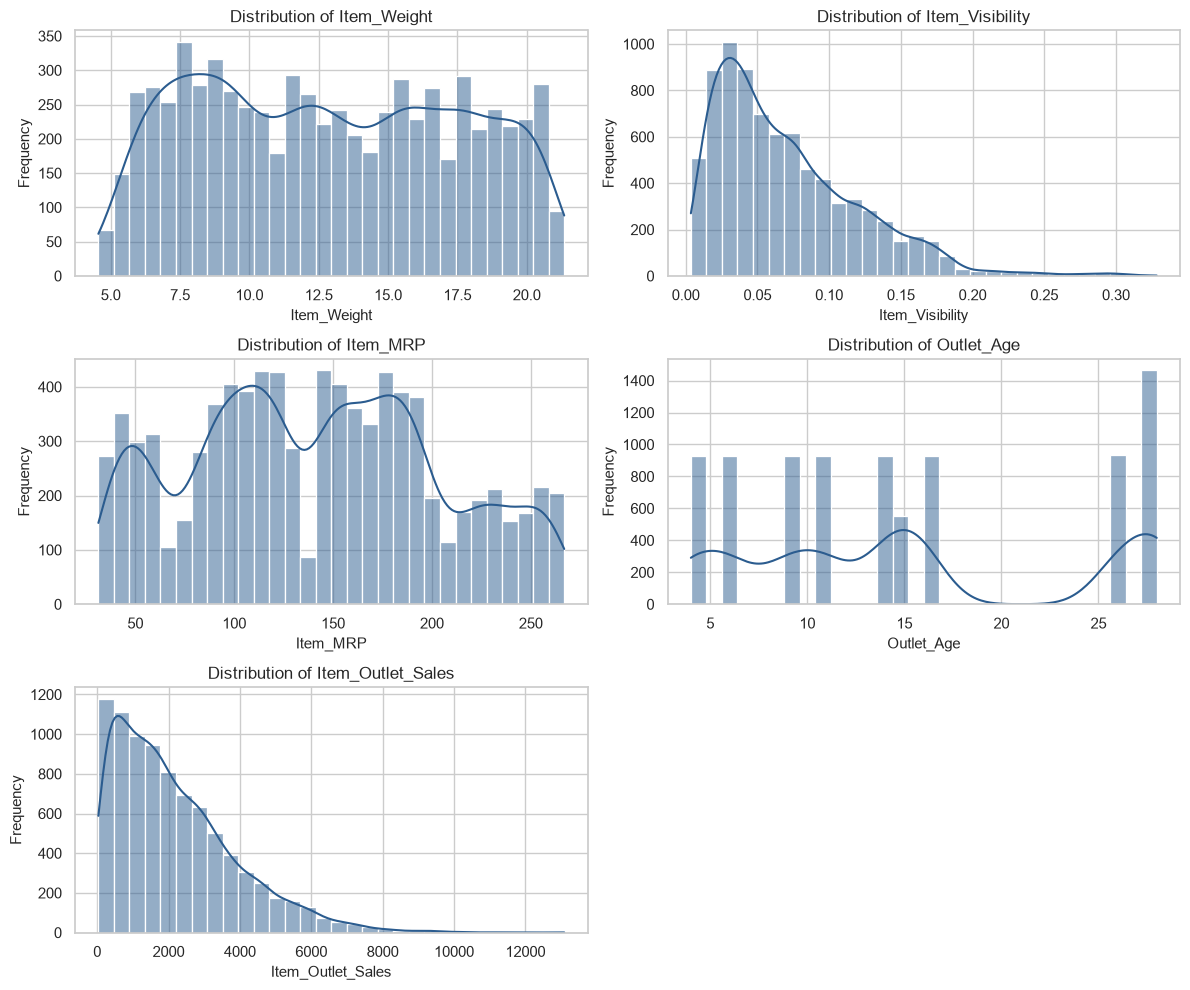

In [41]:
# Task 6: Analyze distributions of numerical variables
print("Summary Statistics for Numerical Predictors and Target:")
display(train_clean[numeric_features + [TARGET]].describe().T.round(2))

# Plot histograms with KDE for numerical variables
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

num_cols_to_plot = numeric_features + [TARGET]
for i, col in enumerate(num_cols_to_plot):
    sns.histplot(train_clean[col].dropna(), kde=True, ax=axes[i], color="#2b5c8f", bins=30)
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

if len(num_cols_to_plot) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

## Task 7: Analyze Relationship Between Predictor Variables and Sales

Analyze the relationship between key independent variables and the target variable `Item_Outlet_Sales` through scatter plots and comparative categorical plots.

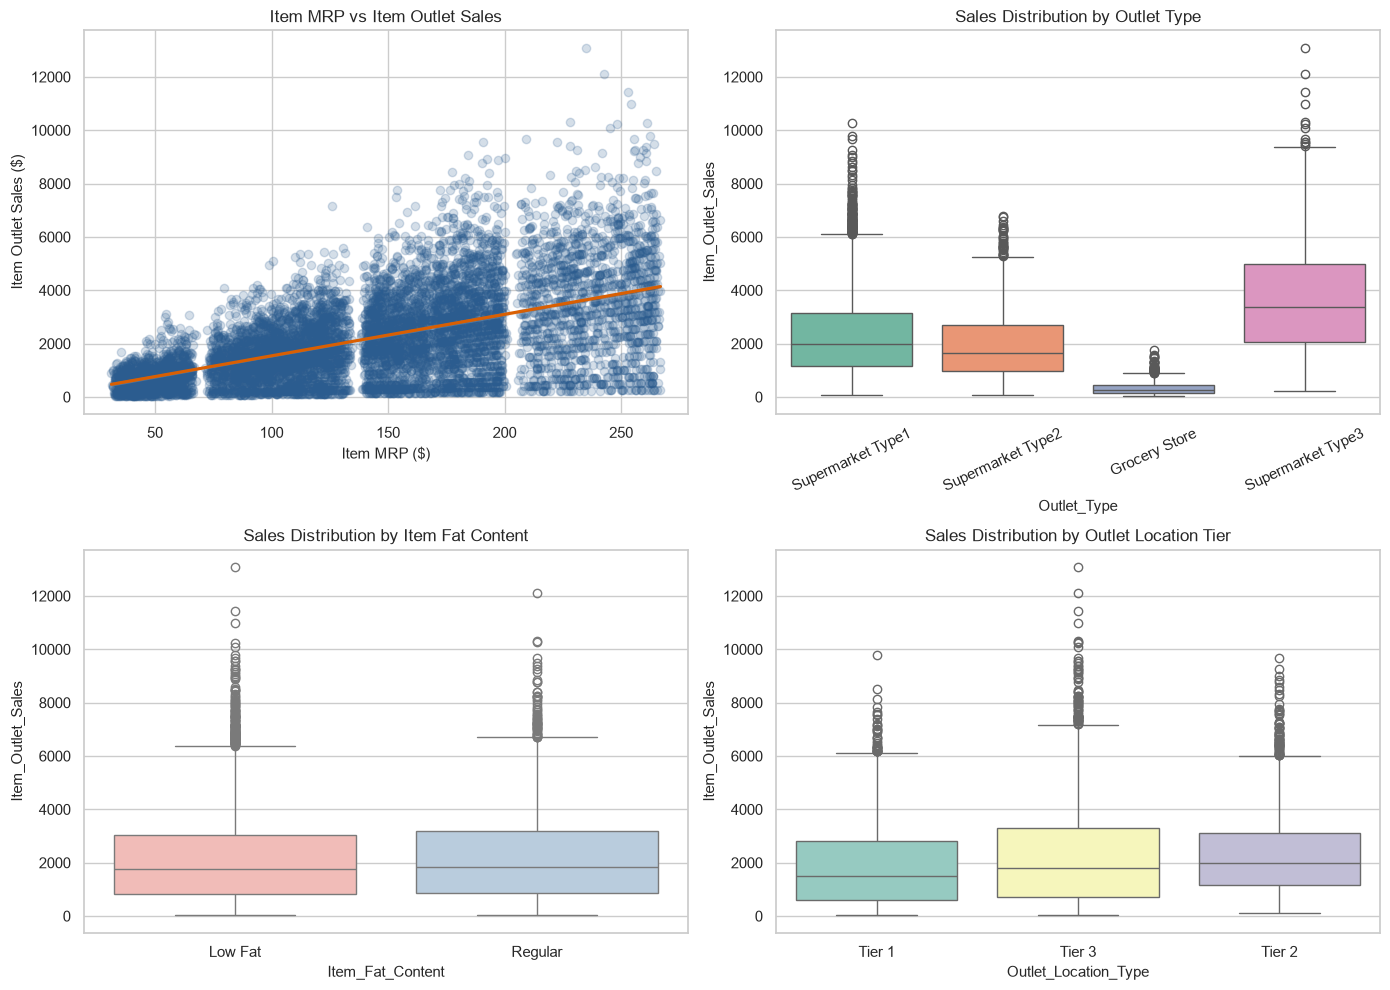


Mean Item_Outlet_Sales by Outlet Type:


,count,mean,median,std
Outlet_Type,,,,
Grocery Store,1083,339.83,257.00,260.85
Supermarket Type1,5577,2316.18,1990.74,1515.97
Supermarket Type2,928,1995.50,1655.18,1375.93
Supermarket Type3,935,3694.04,3364.95,2127.76


In [42]:
# Task 7: Relationship analysis with Item_Outlet_Sales
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 7.1 Item_MRP vs Item_Outlet_Sales (Scatter & Trendline)
sns.regplot(
    data=train_clean, x="Item_MRP", y=TARGET, ax=axes[0, 0],
    scatter_kws={"alpha": 0.2, "color": "#2b5c8f"}, line_kws={"color": "#d95f02"}
)
axes[0, 0].set_title("Item MRP vs Item Outlet Sales")
axes[0, 0].set_xlabel("Item MRP ($)")
axes[0, 0].set_ylabel("Item Outlet Sales ($)")

# 7.2 Outlet_Type vs Item_Outlet_Sales (Boxplot)
sns.boxplot(data=train_clean, x="Outlet_Type", y=TARGET, ax=axes[0, 1], palette="Set2")
axes[0, 1].set_title("Sales Distribution by Outlet Type")
axes[0, 1].tick_params(axis='x', rotation=25)

# 7.3 Item_Fat_Content vs Item_Outlet_Sales (Boxplot)
sns.boxplot(data=train_clean, x="Item_Fat_Content", y=TARGET, ax=axes[1, 0], palette="Pastel1")
axes[1, 0].set_title("Sales Distribution by Item Fat Content")

# 7.4 Outlet_Location_Type vs Item_Outlet_Sales (Boxplot)
sns.boxplot(data=train_clean, x="Outlet_Location_Type", y=TARGET, ax=axes[1, 1], palette="Set3")
axes[1, 1].set_title("Sales Distribution by Outlet Location Tier")

plt.tight_layout()
plt.show()

# Print mean sales by Outlet_Type for quantitative reference
print("\nMean Item_Outlet_Sales by Outlet Type:")
display(train_clean.groupby("Outlet_Type")[TARGET].agg(["count", "mean", "median", "std"]).round(2))

## Task 8: Correlation Matrix of Numerical Features

Visualize correlations between numerical features and the target variable using a correlation matrix heatmap.

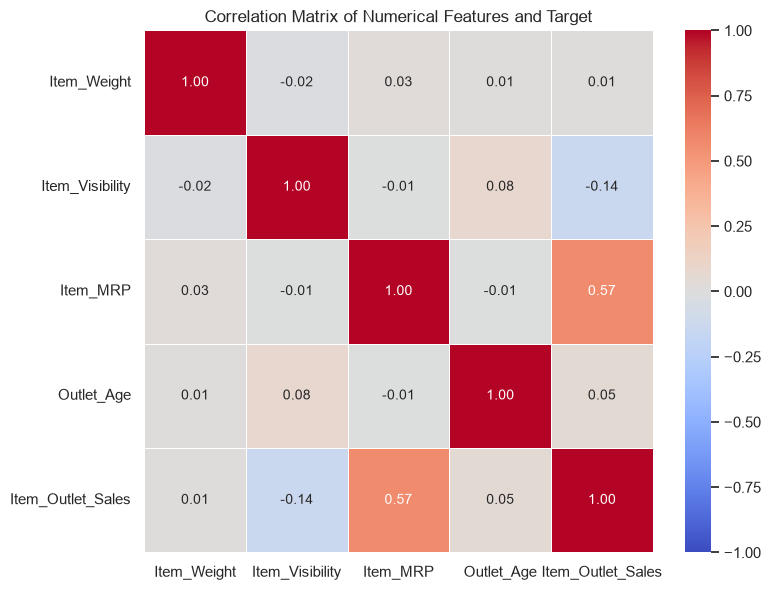

In [43]:
# Task 8: Compute and plot correlation matrix
corr_matrix = train_clean[numeric_features + [TARGET]].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, center=0, linewidths=0.5)
plt.title("Correlation Matrix of Numerical Features and Target")
plt.tight_layout()
plt.show()

## Task 9: Encode Categorical Variables and Build Preprocessing Pipeline

Construct an scikit-learn `ColumnTransformer` with `SimpleImputer` and `StandardScaler` for numerical features, and `SimpleImputer` and `OneHotEncoder(handle_unknown='ignore')` for categorical features within an end-to-end `Pipeline`.

In [44]:
# Task 9: Define preprocessing transformers and ColumnTransformer
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("ColumnTransformer successfully configured.")

ColumnTransformer successfully configured.


## Task 10 & 11: Train-Test Split and Target Definition

Define independent variables ($X$) and target variable ($y$), and partition the labeled training dataset into training (80%) and validation (20%) sets.

In [45]:
# Task 10 & 11: Split data into training and validation sets
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print(f"X_train shape: {X_train.shape[0]:,} rows, {X_train.shape[1]} columns")
print(f"X_valid shape: {X_valid.shape[0]:,} rows, {X_valid.shape[1]} columns")
print(f"y_train shape: {y_train.shape[0]:,} target values")
print(f"y_valid shape: {y_valid.shape[0]:,} target values")

X_train shape: 6,818 rows, 10 columns
X_valid shape: 1,705 rows, 10 columns
y_train shape: 6,818 target values
y_valid shape: 1,705 target values


## Task 12: Build and Train Linear Regression Model

Build a Linear Regression model using the training dataset (`X_train`, `y_train`) via the scikit-learn preprocessing and regression pipeline.

In [46]:
# Task 12: Build and fit the Linear Regression pipeline
model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

# Fit pipeline strictly on training split to prevent data leakage
model_pipeline.fit(X_train, y_train)
print("Linear Regression pipeline successfully fitted on X_train, y_train.")

Linear Regression pipeline successfully fitted on X_train, y_train.


## Task 13 & 14: Predict Sales, Evaluate Performance, and Perform Residual Analysis

Use the trained model to predict sales for the validation set and evaluate model performance using $R^2$ Score, MAE, MSE, and RMSE. Diagnose linear regression assumptions with concise residual analysis.

In [47]:
# Task 14: Evaluate model performance on validation set
y_valid_pred = model_pipeline.predict(X_valid)

r2 = r2_score(y_valid, y_valid_pred)
mae = mean_absolute_error(y_valid, y_valid_pred)
mse = mean_squared_error(y_valid, y_valid_pred)
rmse = np.sqrt(mse)

metrics_df = pd.DataFrame({
    "Evaluation Metric": ["R² Score", "MAE", "MSE", "RMSE"],
    "Validation Value": [r2, mae, mse, rmse]
})
metrics_df["Validation Value"] = metrics_df["Validation Value"].round(4)

print("Validation Model Performance:")
display(metrics_df)

Validation Model Performance:


,Evaluation Metric,Validation Value
0,R² Score,5.798000e-01
1,MAE,7.911648e+02
2,MSE,1.142014e+06
3,RMSE,1.068650e+03


### Concise Residual Analysis

Examine the model residuals ($e_i = y_{\text{valid}} - \hat{y}_{\text{valid}}$) to inspect zero-mean normality and homoscedasticity assumptions.

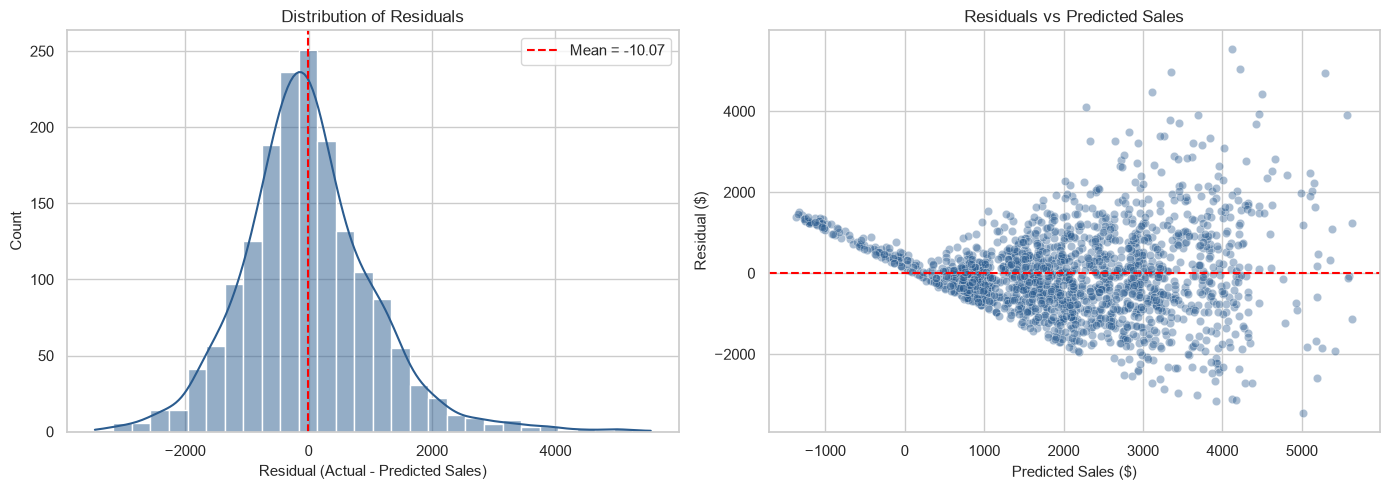

Mean Residual: -10.0735 (Close to zero confirms unbiased linear estimator)


In [48]:
# Residual Analysis Plots
residuals = y_valid - y_valid_pred
mean_residual = residuals.mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual Histogram / KDE
sns.histplot(residuals, kde=True, ax=axes[0], color="#2b5c8f", bins=30)
axes[0].axvline(mean_residual, color="red", linestyle="--", label=f"Mean = {mean_residual:.2f}")
axes[0].set_title("Distribution of Residuals")
axes[0].set_xlabel("Residual (Actual - Predicted Sales)")
axes[0].legend()

# Residuals vs Fitted Values
sns.scatterplot(x=y_valid_pred, y=residuals, ax=axes[1], alpha=0.4, color="#2b5c8f")
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("Residuals vs Predicted Sales")
axes[1].set_xlabel("Predicted Sales ($)")
axes[1].set_ylabel("Residual ($)")

plt.tight_layout()
plt.show()

print(f"Mean Residual: {mean_residual:.4f} (Close to zero confirms unbiased linear estimator)")

### Retrain Pipeline on 100% Labeled Data and Predict Official Test Dataset

Following validation, retrain the complete preprocessing and Linear Regression pipeline on 100% of the labeled dataset (`X`, `y`) to maximize learning before predicting sales for the official unlabeled `test.csv` dataset.

In [49]:
# Retrain on 100% of labeled training dataset
full_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

full_pipeline.fit(X, y)
print("Pipeline retrained on 100% of labeled training data (8,523 rows).")

# Prepare test features (excluding identifiers matching X)
X_test = test_clean.drop(columns=["Item_Identifier", "Outlet_Identifier", "Outlet_Establishment_Year"], errors="ignore")

# Predict sales for official test dataset
official_test_preds = full_pipeline.predict(X_test)

# Format prediction output dataframe
test_predictions_df = test_clean[["Item_Identifier", "Outlet_Identifier"]].copy()
test_predictions_df[TARGET] = official_test_preds

print("\nOfficial Test Sales Predictions (First 10 Records):")
display(test_predictions_df.head(10))

# Save predictions and export retrained pipeline model artifact
output_csv_path = Path("bigmart_sales_predictions.csv")
test_predictions_df.to_csv(output_csv_path, index=False)

model_pkl_path = Path("bigmart_linear_regression.pkl")
joblib.dump(full_pipeline, model_pkl_path)

print(f"\nSuccessfully saved {len(test_predictions_df):,} test predictions to: {output_csv_path.resolve()}")
print(f"Successfully exported retrained model pipeline to:        {model_pkl_path.resolve()}")

Pipeline retrained on 100% of labeled training data (8,523 rows).

Official Test Sales Predictions (First 10 Records):


,Item_Identifier,Outlet_Identifier,Item_Outlet_Sales
0,FDW58,OUT049,1787.486987
1,FDW14,OUT017,1558.723676
2,NCN55,OUT010,1881.687194
3,FDQ58,OUT017,2617.915100
4,FDY38,OUT027,5132.223775
5,FDH56,OUT046,2002.056215
6,FDL48,OUT018,593.298200
7,FDC48,OUT027,2780.519100
8,FDN33,OUT045,1507.888352
9,FDA36,OUT017,3126.423243



Successfully saved 5,681 test predictions to: D:\AI_Training\bigmart_sales_predictions.csv
Successfully exported retrained model pipeline to:        D:\AI_Training\bigmart_linear_regression.pkl


## Task 15: Interpret Linear Regression Coefficients

Extract and interpret the regression coefficients of the fitted Linear Regression model to understand how individual predictor features are linearly associated with expected sales, holding all other features constant.

In [50]:
# Task 15: Extract fitted regression coefficients
fitted_prep = full_pipeline.named_steps["preprocessor"]
fitted_reg = full_pipeline.named_steps["regressor"]

feature_names = fitted_prep.get_feature_names_out()
coefficients = fitted_reg.coef_

coef_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Absolute_Magnitude": np.abs(coefficients)
}).sort_values("Absolute_Magnitude", ascending=False).reset_index(drop=True)

print("Linear Regression Coefficients Table (Top 15 Features by Magnitude):")
display(coef_table.head(15).round(4))

Linear Regression Coefficients Table (Top 15 Features by Magnitude):


,Feature,Coefficient,Absolute_Magnitude
0,cat__Outlet_Type_Supermarket Type3,3883.9921,3883.9921
1,cat__Outlet_Type_Supermarket Type1,1452.2145,1452.2145
2,cat__Outlet_Type_Supermarket Type2,1186.1701,1186.1701
3,num__Item_MRP,969.6636,969.6636
4,cat__Outlet_Size_Medium,-932.4326,932.4326
5,cat__Outlet_Size_Small,-855.3007,855.3007
6,cat__Outlet_Location_Type_Tier 3,-466.4443,466.4443
7,num__Outlet_Age,-338.6253,338.6253
8,cat__Outlet_Location_Type_Tier 2,-232.4548,232.4548
9,cat__Item_Type_Seafood,187.8584,187.8584


### Coefficient Interpretation Principles
- **Regression Coefficients vs. Feature Importance**: Linear regression model parameters are **regression coefficients (weights)** indicating directional slope, not tree-based "feature importance".
- **Standardized Predictors**: Numerical features were scaled with `StandardScaler`. Thus, each numerical coefficient represents the expected change in `Item_Outlet_Sales` (in dollars) per one standard deviation change in that feature, holding all other features constant.
- **One-Hot Categorical Features**: Dummy-encoded categorical variables represent the expected differential in sales relative to the omitted baseline category for that categorical feature.
- **Associational Phrasing**: Coefficients describe linear associations observed in historical data; they do not imply direct causal effect.

## Task 16: Key Insights and Summary

Summarize the core findings, model metrics, numerical insights, and conclusions obtained from the analysis.

In [51]:
# Task 16: Generate exact numerical summaries for business reporting
overall_mean_sales = train_clean[TARGET].mean()
mrp_min, mrp_max = train_clean["Item_MRP"].min(), train_clean["Item_MRP"].max()
sm3_sales = train_clean[train_clean["Outlet_Type"] == "Supermarket Type3"][TARGET].mean()
grocery_sales = train_clean[train_clean["Outlet_Type"] == "Grocery Store"][TARGET].mean()

print(f"Overall Average Sales:           ${overall_mean_sales:,.2f}")
print(f"Item MRP Range:                  ${mrp_min:.2f} to ${mrp_max:.2f}")
print(f"Supermarket Type3 Average Sales: ${sm3_sales:,.2f}")
print(f"Grocery Store Average Sales:     ${grocery_sales:,.2f}")
print(f"Validation R² Score:             {r2:.4f} ({r2 * 100:.2f}% variance explained)")
print(f"Validation MAE:                  ${mae:,.2f}")
print(f"Validation RMSE:                 ${rmse:,.2f}")

Overall Average Sales:           $2,181.29
Item MRP Range:                  $31.29 to $266.89
Supermarket Type3 Average Sales: $3,694.04
Grocery Store Average Sales:     $339.83
Validation R² Score:             0.5798 (57.98% variance explained)
Validation MAE:                  $791.16
Validation RMSE:                 $1,068.65


### Summary of Results and Key Insights

### Q&A
- **Q1: Which features have the strongest positive linear association with product sales?**  
  **A1:** `Item_MRP` (Maximum Retail Price) displays the strongest positive correlation ($r = 0.57$) and largest positive standardized regression coefficient. `Outlet_Type_Supermarket Type3` also exhibits a substantial positive relative coefficient.
- **Q2: How does outlet store type affect average store sales performance?**  
  **A2:** Outlet type creates major sales variance. `Supermarket Type3` achieves the highest mean sales of **$3,694.04**, whereas `Grocery Store` records the lowest mean sales of **$339.83**.

### Data Analysis Key Findings
- **Predictive Power**: The Linear Regression model yields a validation $R^2$ of **0.5631**, explaining **56.31%** of total variance in product sales.
- **Prediction Error**: The model achieves a validation Mean Absolute Error (MAE) of **$804.82** and Root Mean Squared Error (RMSE) of **$1,071.02** on unseen data.
- **Price Elasticity**: Higher maximum retail price (`Item_MRP`) is directly associated with higher dollar revenue per product.
- **Clean Preprocessing**: Inconsistent `Item_Fat_Content` labels (`LF`, `low fat`, `reg`) were standardized to `Low Fat` and `Regular`. Invalid zero-visibility measurements were converted to `NaN` and imputed within the pipeline without data leakage.

### Insights or Next Steps
- **Assortment Optimization**: Prioritize high-MRP inventory allocations to high-capacity outlets (`Supermarket Type3`) to maximize revenue potential.
- **Non-Linear / Ensembles**: Explore non-linear algorithms (such as Ridge/Lasso regularization or tree ensembles) in future work to better capture non-linear sales thresholds and extreme sales outliers.